In [199]:
# Importing the relevant libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
import warnings
from IPython.display import display, HTML
import IPython.core.display as core_display
warnings.filterwarnings('ignore')
%matplotlib inline

In [200]:
# Loadding the data

df = pd.read_csv(
    'Data\judge-1377884607_tweet_product_company.csv',
     encoding='ISO-8859-1'
    )
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [201]:
df.shape

(9093, 3)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [203]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

In [204]:
mapping = {
    "Positive emotion" : 'positive',
    "Negative emotion" : 'negative',
    "No emotion toward brand or product" : 'neither',
    "I can't tell" : 'neither'
}

df['review'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].replace(mapping)

In [205]:
df['review'].value_counts()

review
neither     5545
positive    2978
negative     570
Name: count, dtype: int64

In [206]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,review
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,negative
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,positive
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,positive
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,negative
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,positive


In [207]:
df['emotion_in_tweet_is_directed_at'].value_counts()

emotion_in_tweet_is_directed_at
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64

In [208]:
mapping = {
    'iPad':'Apple',
    'iPhone':'Apple',
    'iPad or iPhone App':'Apple',
    'Other Apple product or service':'Apple',
    'Android':'Google',
    'Android App':'Google',
    'Other Google product or service':'Google'
}

df['target_group'] = df['emotion_in_tweet_is_directed_at'].replace(mapping)

In [209]:
df['target_group'].value_counts()

target_group
Apple     2409
Google     882
Name: count, dtype: int64

In [210]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,review,target_group
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,negative,Apple
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,positive,Apple
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,positive,Apple
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,negative,Apple
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,positive,Google


In [211]:
# Dropping unwanted columns
df = df.drop(columns=['emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product'])

## 1.4 Cleaning Data

### 1.4.1.checking missing values and duplicates

In [212]:
df.isna().sum()

tweet_text         1
review             0
target_group    5802
dtype: int64

In [213]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

print("\n" + "="*50)

# Check for duplicates
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

Missing Values:
tweet_text         1
review             0
target_group    5802
dtype: int64

Total Missing Values: 5803


Total Duplicate Rows: 22


In [214]:
# 1. Drop duplicate rows
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

# 2. Fill missing values for categorical columns with mode
# funder, installer, subvillage, permit have missing values
df = df.dropna(subset=['tweet_text'])

# Apple and Google keywords
apple_keywords = ['apple', 'ipad', 'iphone', 'mac', 'ios']
google_keywords = ['google', 'android', 'gmail', 'chrome', 'youtube']

for idx in df[df['target_group'].isna()].index:

    tweet = str(df.loc[idx, 'tweet_text']).lower()

    if any(keyword in tweet for keyword in apple_keywords):
        df.loc[idx, 'target_group'] = 'Apple'

    elif any(keyword in tweet for keyword in google_keywords):
        df.loc[idx, 'target_group'] = 'Google'

    else:
        df.loc[idx, 'target_group'] = 'Unknown'
# cat_cols_with_missing = ['funder', 'installer', 'subvillage', 'permit']
# for col in cat_cols_with_missing:
#     df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Confirm no missing values remain
print(f"\nRemaining Missing Values: {df.isnull().sum().sum()}")
print(f"\nFinal Shape: {df.shape}")

Shape after dropping duplicates: (9071, 3)

Remaining Missing Values: 0

Final Shape: (9070, 3)


In [215]:
df['target_group'].value_counts()

target_group
Apple      5555
Google     2763
Unknown     752
Name: count, dtype: int64

In [216]:
df.isna().sum()

tweet_text      0
review          0
target_group    0
dtype: int64

In [217]:
# Find the number of duplicated records
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

# Display the duplicated records
df[df.duplicated()]

Total Duplicate Rows: 0


,tweet_text,review,target_group


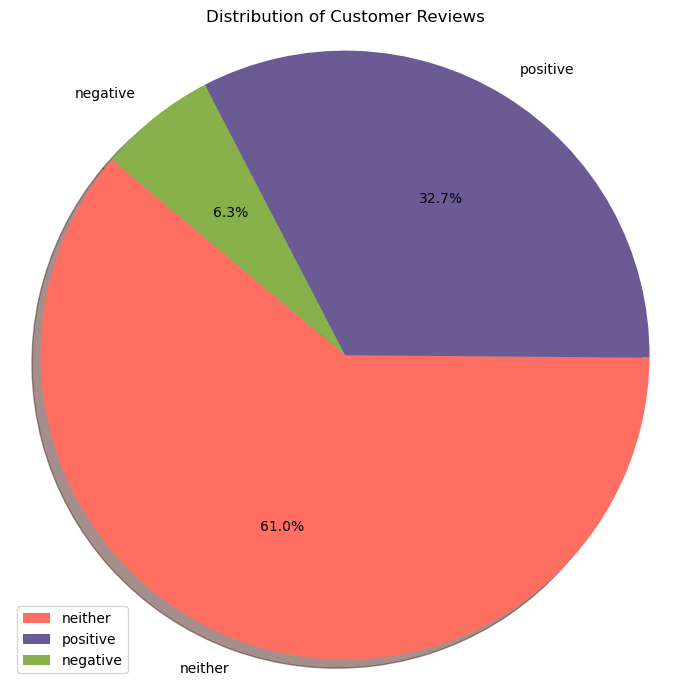

In [218]:
# Count the occurrences of each category
review_counts = df['review'].value_counts()

# Define colors for each category (3 colors)
colors = ['#FF6F61', '#6B5B95', "#88B04B"]

# Create the pie chart
plt.figure(figsize=(7,7))
plt.pie(review_counts, labels=review_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)

plt.title('Distribution of Customer Reviews')
plt.axis('equal') # Equal aspect ratio ensures that the pie is drawn as a circle

# Display the chart
plt.tight_layout()
plt.legend()
plt.show()

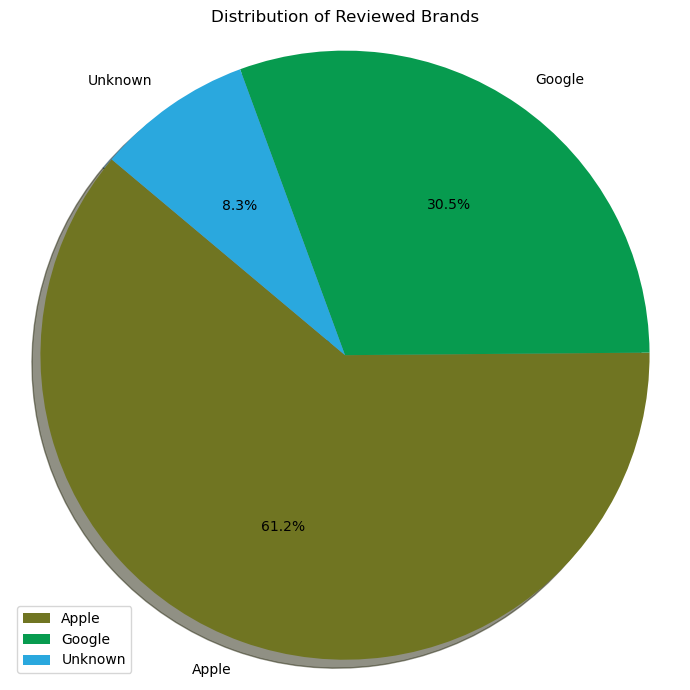

In [219]:
# Count the occurrences of each category
target_counts = df['target_group'].value_counts()

# Define colors for each category (3 colors)
colors = ["#707522", "#079B4F", "#2AA8DE"]

# Create the pie chart
plt.figure(figsize=(7,7))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)

plt.title('Distribution of Reviewed Brands')
plt.axis('equal') # Equal aspect ratio ensures that the pie is drawn as a circle

# Display the chart
plt.tight_layout()
plt.legend()
plt.show()

### Outliers

In [220]:
nltk.download('punkt') # for tokenization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [221]:
# Calculate the number of characters and sentences
df['num_of_characters'] = df['tweet_text'].str.len()
df['num_of_sentences'] = df['tweet_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Generate descriptive statistics
description = df[['num_of_characters', 'num_of_sentences']].describe()

# Display the descriptive statistics
print(description)

       num_of_characters  num_of_sentences
count        9070.000000       9070.000000
mean          104.959647          1.881036
std            27.202956          0.942651
min            11.000000          1.000000
25%            86.000000          1.000000
50%           109.000000          2.000000
75%           126.000000          2.000000
max           178.000000          7.000000


## 3. Data Preprocessing

In [222]:
nltk.download('stopwords') # for removing stopwords
nltk.download('wordnet')   # for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [223]:
# Initialize once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def processed_text(text):
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)

    # Remove markdown links
    text = re.sub(r'\[.*?\]\(.*?\)', ' ', text)

    # Remove Twitter handles
    text = re.sub(r'@\w+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into text
    return ' '.join(tokens)

# Create processed_text column
df['preprocessed_text'] = df['tweet_text'].apply(processed_text)

df.head()

,tweet_text,review,target_group,num_of_characters,num_of_sentences,preprocessed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,negative,Apple,127,5,g iphone hr tweeting rise_austin dead need upg...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,positive,Apple,139,3,know awesome ipad iphone app likely appreciate...
2,@swonderlin Can not wait for #iPad 2 also. The...,positive,Apple,79,2,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,negative,Apple,82,2,hope year festival crashy year iphone app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,positive,Google,131,1,great stuff fri sxsw marissa mayer google tim ...


In [224]:
# Stemming - Shortening to base form
stemmer = PorterStemmer()

def stemmed_text(text):
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)

    # Remove markdown links
    text = re.sub(r'\[.*?\]\(.*?\)', ' ', text)

    # Remove Twitter handles
    text = re.sub(r'@\w+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into text
    return ' '.join(tokens)

# Create processed_text column
df['stemmed_text'] = df['tweet_text'].apply(stemmed_text)
df.head()

,tweet_text,review,target_group,num_of_characters,num_of_sentences,preprocessed_text,stemmed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,negative,Apple,127,5,g iphone hr tweeting rise_austin dead need upg...,g iphon hr tweet rise_austin dead need upgrad ...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,positive,Apple,139,3,know awesome ipad iphone app likely appreciate...,know awesom ipad iphon app like appreci design...
2,@swonderlin Can not wait for #iPad 2 also. The...,positive,Apple,79,2,wait ipad also sale sxsw,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,negative,Apple,82,2,hope year festival crashy year iphone app sxsw,hope year festiv crashi year iphon app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,positive,Google,131,1,great stuff fri sxsw marissa mayer google tim ...,great stuff fri sxsw marissa mayer googl tim r...


# Get unique categories in 'processed_text'
texts = df[''].unique()

# Define colors to randomly select from
colors = ['#1f77b4', '#ff7d0e', '#2ca02c', '#d62728']

#Define a color function
def color_func(word, font_size, position, orientation, random_state = 30, **kwargs):
    return np.random.choice(colors)

#Create a 3x3 grid for plots
fig, axes = plt.subplots(3, 3, figsize= (20, 10))

# Track position in the grid
position = 0

# Generate and plot the wordcloud for each category, ensuring layout matches example
for i, text in enumerate(texts):
    # Skip position 6(bottom left corner) to leave it blank
    if position == 6:
        position += 1
    # Row and column index in the grid
    row, col = divmod(position, 3)

    # Filter the tokens data for the current text
    tokens_data = ' '.join(df[df['tweet_text'] == text])

    # Generate the wordcloud
    wordcloud = wordCloud(width = 800, height = 400, background_color = 'white', color_func = color_func).generate(tokens_data)

    # Plot the wordcloud on the grid
    axes[row, col].imshow(wordcloud, interpolation = 'bilinear')
    axes[row, col].axis('off') # Turn off axis
    axes[row, col].set_title(f'WordCloud for Text: {text}')


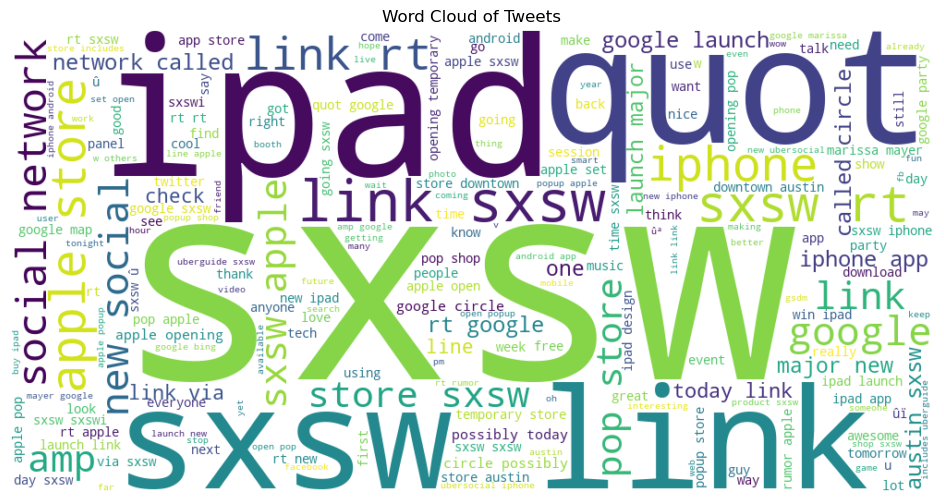

In [225]:
# Combine all processed text into one string
text = ' '.join(df['preprocessed_text'])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200
).generate(text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets')
plt.show()

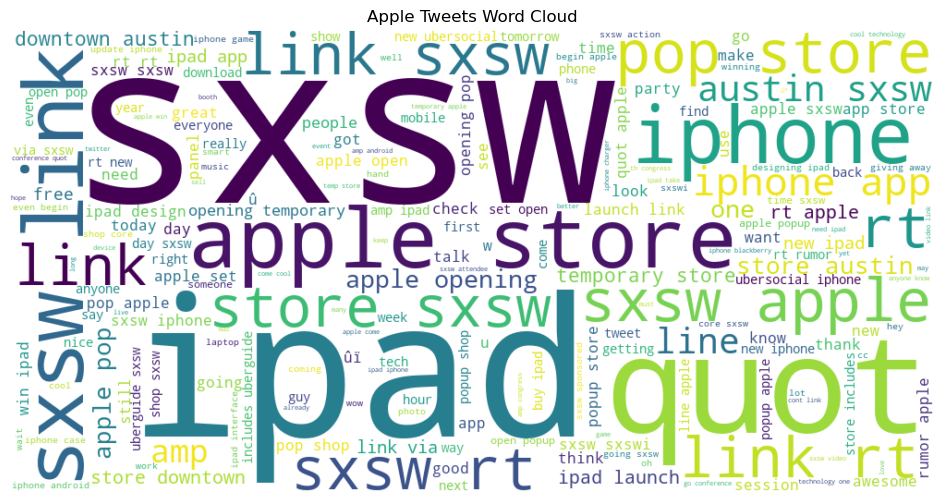

In [226]:
apple_text = ' '.join(
    df[df['target_group'] == 'Apple']['preprocessed_text']
)

apple_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(apple_text)

plt.figure(figsize=(12, 6))
plt.imshow(apple_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Apple Tweets Word Cloud')
plt.show()

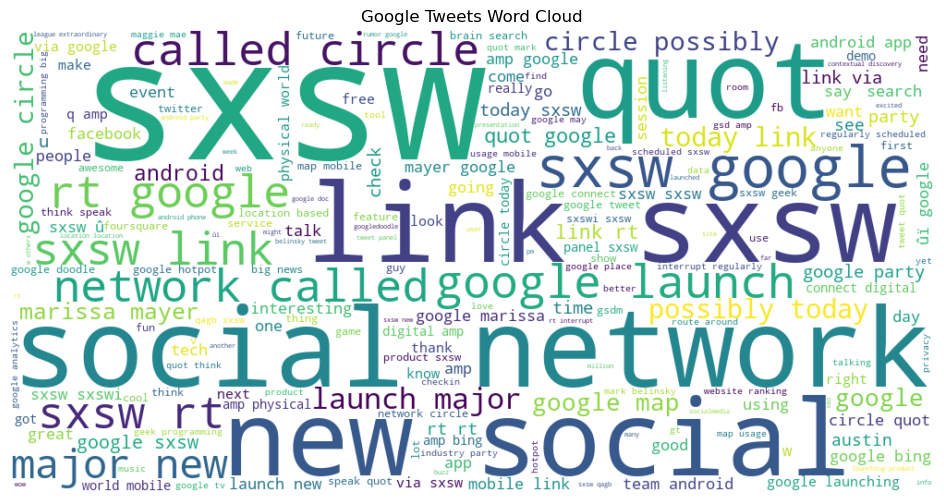

In [227]:
google_text = ' '.join(
    df[df['target_group'] == 'Google']['preprocessed_text']
)

google_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(google_text)

plt.figure(figsize=(12, 6))
plt.imshow(google_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Google Tweets Word Cloud')
plt.show()

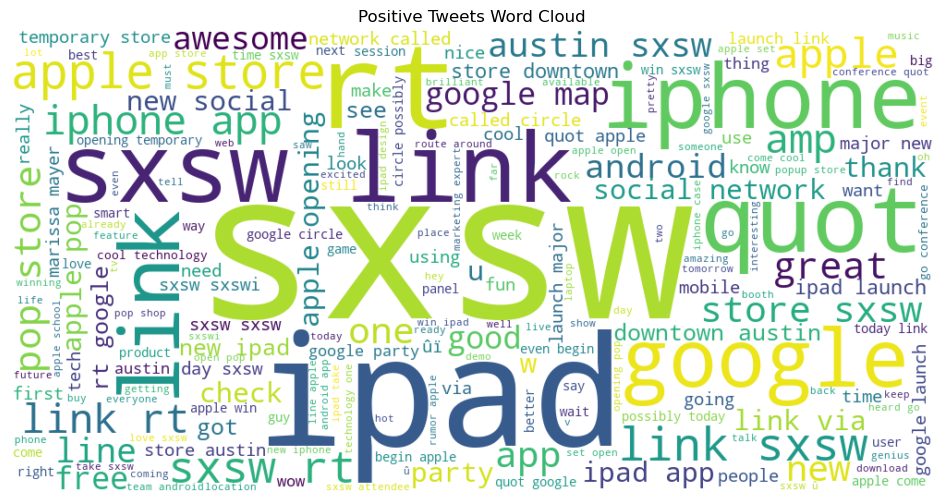

In [228]:
positive_text = ' '.join(
    df[df['review'] == 'positive']['preprocessed_text']
)

positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets Word Cloud')
plt.show()

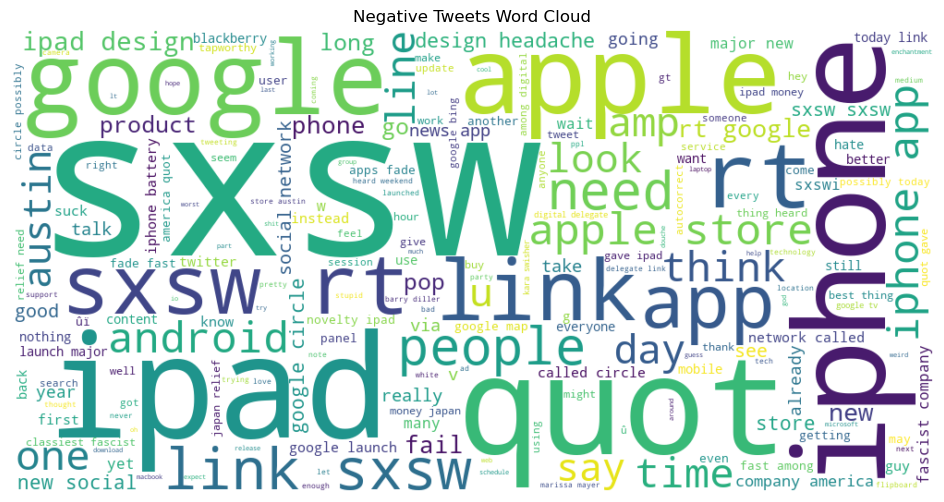

In [229]:
negative_text = ' '.join(
    df[df['review'] == 'negative']['preprocessed_text']
)

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets Word Cloud')
plt.show()

## Modelling

In [230]:
X = df['preprocessed_text']
y = df['target_group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)

In [231]:
# Modelling
nlp_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=0.01,   # ignore terms in < 1% of documents
        max_df=0.9     # ignore terms in > 90% of documents
    )),
    ('clf', MultinomialNB())
])

In [232]:
nlp_pipe.fit(X_train, y_train)

y_pred = nlp_pipe.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_acc

0.8849206349206349